# 🏏 IPL — Batter vs Spin Bowling · Prediction Model v4

A clean, production-ready notebook that trains the full v3 model pipeline
and exports all artefacts used by `app.py`.

| Step | What happens |
|------|-------------|
| 1 | Imports |
| 2 | Load data (CSV + optional Cricsheet JSON) |
| 3 | Clean & standardise |
| 4 | Identify spin deliveries |
| 5 | Feature engineering (batter, venue, form, ball-level) |
| 6 | KMeans batter clustering |
| 7 | Build model dataset |
| 8 | Train & compare RF / XGBoost / LightGBM |
| 9 | Hyperparameter tuning (best model) |
| 10 | SHAP explainability |
| 11 | Validation |
| 12 | Prediction functions |
| 13 | Monte Carlo simulation |
| 14 | Full-match prediction |
| 15 | Save all artefacts |

**Files required in the same folder:**

| File | Required |
|------|----------|
| `Ball_By_Ball_Match_Data.csv` | ✅ |
| `2026_players_details.csv` | ✅ |
| `Match_Info.csv` | ✅ |
| Cricsheet JSON folder | optional |

**Files produced (all used by `app.py`):**

`model_runs.pkl` · `model_wicket.pkl` · `encoder_spin.pkl` · `encoder_phase.pkl`
· `model_kmeans.pkl` · `scaler_cluster.pkl` · `batter_features.csv`
· `venue_features.csv` · `form_features.csv`


## 📦 Step 1 — Imports

In [17]:
import json, glob, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingClassifier)
from sklearn.cluster import KMeans
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.metrics import (mean_absolute_error, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

import xgboost as xgb
import lightgbm as lgb
import shap

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

print(f'✅ Libraries loaded  |  XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}  |  SHAP {shap.__version__}')


✅ Libraries loaded  |  XGBoost 3.2.0  |  LightGBM 4.6.0  |  SHAP 0.51.0


## 📂 Step 2 — Config & Load Data

In [18]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_FOLDER = '.'                   # folder containing this notebook + CSVs
JSON_FOLDER = '../json/ipl_match'   # Cricsheet JSON folder (leave as-is if not using)
SKIP_JSON   = {'teams_info.json'}   # JSON files to ignore

SPIN_TYPES = [
    'right-arm offbreak',
    'legbreak',
    'legbreak googly',
    'slow left-arm orthodox',
    'left-arm wrist-spin',
]

TEAM_ALIAS = {
    'Kings XI Punjab'             : 'Punjab Kings',
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Deccan Chargers'             : 'Sunrisers Hyderabad',
}

# ── Load required CSVs ────────────────────────────────────────────────────────
balls   = pd.read_csv(os.path.join(DATA_FOLDER, 'Ball_By_Ball_Match_Data.csv'))
players = pd.read_csv(os.path.join(DATA_FOLDER, '2026_players_details.csv'))
matches = pd.read_csv(os.path.join(DATA_FOLDER, 'Match_Info.csv'))

print(f'Ball_By_Ball : {len(balls):,} rows')
print(f'Players      : {len(players):,} rows')
print(f'Matches      : {len(matches):,} rows')


Ball_By_Ball : 278,205 rows
Players      : 261 rows
Matches      : 1,169 rows


In [19]:
# ── Optional: Load Cricsheet JSON files ───────────────────────────────────────
def parse_cricsheet(filepath):
    """Parse one Cricsheet JSON file → list of delivery dicts."""
    match_id = os.path.splitext(os.path.basename(filepath))[0]
    rows = []
    try:
        with open(filepath, encoding='utf-8') as f:
            m = json.load(f)
    except Exception as e:
        print(f'  ⚠ Could not read {filepath}: {e}')
        return rows

    info  = m.get('info', {})
    teams = info.get('teams', [])

    for inn_idx, inn in enumerate(m.get('innings', [])):
        bt = inn.get('team', '')
        for od in inn.get('overs', []):
            ov = od.get('over', -1)
            for bn, ball in enumerate(od.get('deliveries', [])):
                extras = ball.get('extras', {})
                runs   = ball.get('runs', {})
                wkts   = ball.get('wickets', [])
                rows.append({
                    'ID'              : match_id,
                    'Innings'         : inn_idx + 1,
                    'Overs'           : ov,
                    'BallNumber'      : bn + 1,
                    'Batter'          : ball.get('batter', ''),
                    'Bowler'          : ball.get('bowler', ''),
                    'BatsmanRun'      : runs.get('batter', 0),
                    'ExtrasRun'       : runs.get('extras', 0),
                    'TotalRun'        : runs.get('total', 0),
                    'IsWicketDelivery': int(bool(wkts)),
                    'Kind'            : wkts[0].get('kind', '') if wkts else '',
                    'ExtraType'       : ('wides'   if 'wides'   in extras else
                                        'noballs' if 'noballs' in extras else np.nan),
                    'BattingTeam'     : bt,
                    'venue'           : info.get('venue', ''),
                })
    return rows


json_files = [
    f for f in sorted(glob.glob(os.path.join(JSON_FOLDER, '*.json')))
    if os.path.basename(f) not in SKIP_JSON
]
print(f'Found {len(json_files)} Cricsheet JSON files', end='')

all_json_rows = []
for i, fp in enumerate(json_files):
    all_json_rows.extend(parse_cricsheet(fp))
    if (i + 1) % 200 == 0 or (i + 1) == len(json_files):
        print(f'  Parsed {i+1}/{len(json_files)} — {len(all_json_rows):,} deliveries', end='\r')

json_balls = pd.DataFrame(all_json_rows) if all_json_rows else pd.DataFrame()
print(f'\nDone. JSON deliveries: {len(json_balls):,}')


  Parsed 1209/1209 — 287,513 deliveries 200/1209 — 47,542 deliveries
Done. JSON deliveries: 287,513


## 🧹 Step 3 — Clean & Merge

In [20]:
COMMON_COLS = ['ID','Innings','Overs','BallNumber','Batter','Bowler',
               'BatsmanRun','ExtrasRun','TotalRun','IsWicketDelivery',
               'Kind','ExtraType','BattingTeam']

balls_clean = balls[COMMON_COLS].copy()

if not json_balls.empty:
    json_clean = json_balls[COMMON_COLS].copy()
    csv_ids    = set(balls_clean['ID'].astype(str))
    json_new   = json_clean[~json_clean['ID'].astype(str).isin(csv_ids)]
    all_balls  = pd.concat([balls_clean, json_new], ignore_index=True)
    print(f'New rows from JSON : {len(json_new):,}')
else:
    all_balls = balls_clean.copy()

# Attach season + venue from Match_Info
matches['match_date'] = pd.to_datetime(matches['match_date'])
matches['season']     = matches['match_date'].dt.year
all_balls = all_balls.merge(
    matches[['match_number', 'season', 'venue']].rename(columns={'match_number': 'ID'}),
    on='ID', how='left'
)

# Standardise team names and fix player data
all_balls['BattingTeam']         = all_balls['BattingTeam'].replace(TEAM_ALIAS)
players['longBowlingStyles']     = players['longBowlingStyles'].replace('Na', np.nan)

# Remove duplicates
dupes = all_balls.duplicated().sum()
all_balls.drop_duplicates(inplace=True)

print(f'Total deliveries : {len(all_balls):,}  ({dupes} duplicates removed)')
print(f'Seasons          : {sorted(all_balls["season"].dropna().astype(int).unique())}')
print(f'Missing values   :\n{all_balls.isnull().sum()[all_balls.isnull().sum() > 0]}')


New rows from JSON : 9,308
Total deliveries : 287,513  (0 duplicates removed)
Seasons          : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Missing values   :
Kind         264382
ExtraType    271914
season         9308
venue          9308
dtype: int64


## 🌀 Step 4 — Identify Spin Deliveries

In [21]:
# Build name → spin-type lookup from players CSV
spin_map = {
    row['Name']: row['longBowlingStyles']
    for _, row in players.iterrows()
    if row['longBowlingStyles'] in SPIN_TYPES
}
print(f'Spin bowlers identified : {len(spin_map)}')
print(players[players['longBowlingStyles'].isin(SPIN_TYPES)]['longBowlingStyles'].value_counts())

# Remove illegal deliveries (wides, no-balls — batter doesn't face them)
legal = all_balls[~all_balls['ExtraType'].isin(['wides', 'noballs'])].copy()

# Filter to spin deliveries only
spin             = legal[legal['Bowler'].isin(spin_map)].copy()
spin['spin_type'] = spin['Bowler'].map(spin_map)
spin['phase']     = pd.cut(
    spin['Overs'], bins=[-1, 5, 14, 19],
    labels=['powerplay', 'middle', 'death']
)

print(f'\nLegal deliveries      : {len(legal):,}')
print(f'Spin deliveries       : {len(spin):,}  ({len(spin)/len(legal)*100:.1f}%)')
print(f'Unique batters vs spin: {spin["Batter"].nunique()}')


Spin bowlers identified : 116
longBowlingStyles
right-arm offbreak        55
slow left-arm orthodox    26
legbreak                  20
legbreak googly           13
left-arm wrist-spin        2
Name: count, dtype: int64

Legal deliveries      : 276,832
Spin deliveries       : 60,475  (21.8%)
Unique batters vs spin: 547


## ⚙️ Step 5 — Feature Engineering

Four feature sets are built:
1. **Batter career stats** vs spin (SR, avg, dot%, boundary%, wicket rate …)
2. **Venue spin stats** (how spin-friendly is each ground?)
3. **Recent form** (rolling SR across last 5 innings vs spin)
4. **Ball-level context** (position in over, interaction terms)


In [22]:
# ── 5a: Batter career stats vs spin ──────────────────────────────────────────
def build_batter_features(spin_df):
    """Compute career batting stats vs spin for every batter."""
    bf = spin_df.groupby('Batter').agg(
        total_balls      = ('BatsmanRun', 'count'),
        total_runs       = ('BatsmanRun', 'sum'),
        dismissals       = ('IsWicketDelivery', 'sum'),
        dots             = ('BatsmanRun', lambda x: (x == 0).sum()),
        fours            = ('BatsmanRun', lambda x: (x == 4).sum()),
        sixes            = ('BatsmanRun', lambda x: (x == 6).sum()),
        ones             = ('BatsmanRun', lambda x: (x == 1).sum()),
        twos             = ('BatsmanRun', lambda x: (x == 2).sum()),
    ).reset_index()

    bf['sr']           = bf['total_runs'] / bf['total_balls'] * 100
    bf['avg']          = (bf['total_runs'] / bf['dismissals'].replace(0, np.nan)).fillna(bf['total_runs'])
    bf['dot_pct']      = bf['dots']  / bf['total_balls'] * 100
    bf['boundary_pct'] = (bf['fours'] + bf['sixes']) / bf['total_balls'] * 100
    bf['six_pct']      = bf['sixes'] / bf['total_balls'] * 100
    bf['wkt_rate']     = bf['dismissals'] / bf['total_balls'] * 100
    bf['rotation_pct'] = (bf['ones'] + bf['twos']) / bf['total_balls'] * 100
    return bf


batter_feats = build_batter_features(spin)
print(f'Batter features : {batter_feats.shape}')

# Preview top batters by volume
batter_feats[batter_feats['total_balls'] >= 50].sort_values('sr', ascending=False).head(8)[
    ['Batter', 'total_balls', 'sr', 'avg', 'dot_pct', 'boundary_pct', 'wkt_rate']
].round(2)


Batter features : (547, 16)


,Batter,total_balls,sr,avg,dot_pct,boundary_pct,wkt_rate
459,SP Narine,238,197.48,19.58,35.29,31.93,10.08
372,Priyansh Arya,76,197.37,21.43,25.00,27.63,9.21
515,V Suryavanshi,67,194.03,21.67,37.31,29.85,8.96
52,Abhishek Sharma,360,190.28,36.05,25.28,25.56,5.28
354,PD Salt,156,185.90,26.36,28.85,30.77,7.05
92,C Connolly,65,184.62,60.00,26.15,26.15,3.08
57,Aniket Verma,72,181.94,21.83,31.94,25.00,8.33
513,V Sehwag,137,177.37,34.71,21.90,23.36,5.11


In [23]:
# ── 5b: Venue spin features ──────────────────────────────────────────────────
def build_venue_features(spin_df, min_deliveries=50):
    """
    Per-venue spin stats:
    - venue_spin_wkt_rate : how often spinners take wickets here
    - venue_spin_economy  : average runs per ball off spin here
    High wkt_rate + low economy = spin-friendly venue.
    """
    vf = spin_df.groupby('venue').agg(
        venue_spin_wkt_rate = ('IsWicketDelivery', 'mean'),
        venue_spin_economy  = ('BatsmanRun', 'mean'),
        venue_deliveries    = ('BatsmanRun', 'count'),
    ).reset_index()
    return vf[vf['venue_deliveries'] >= min_deliveries].drop(columns='venue_deliveries').reset_index(drop=True)


# ── Clean duplicate venue names BEFORE building features ─────────────────────
venue_clean = {
    'Wankhede Stadium, Mumbai':                                              'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru':                                      'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium':                                                 'M Chinnaswamy Stadium',
    'Eden Gardens, Kolkata':                                                 'Eden Gardens',
    'MA Chidambaram Stadium, Chepauk':                                       'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai':                              'MA Chidambaram Stadium',
    'Arun Jaitley Stadium, Delhi':                                           'Arun Jaitley Stadium',
    'Rajiv Gandhi International Stadium, Uppal':                             'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad':                  'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali':                  'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh':      'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association Stadium, Mohali':                            'Punjab Cricket Association IS Bindra Stadium',
    'Narendra Modi Stadium, Ahmedabad':                                      'Narendra Modi Stadium',
    'Maharashtra Cricket Association Stadium, Pune':                         'Maharashtra Cricket Association Stadium',
    'Sawai Mansingh Stadium, Jaipur':                                        'Sawai Mansingh Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':              'Himachal Pradesh Cricket Association Stadium',
    'Brabourne Stadium, Mumbai':                                             'Brabourne Stadium',
    'Barsapara Cricket Stadium, Guwahati':                                   'Barsapara Cricket Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow':'Ekana Cricket Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur':    'New Chandigarh Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh':'New Chandigarh Stadium',
    'Dr DY Patil Sports Academy, Mumbai':                                    'Dr DY Patil Sports Academy',
}

spin['venue'] = spin['venue'].replace(venue_clean)
print(f'Unique venues after cleaning: {spin["venue"].nunique()}')

venue_feats = build_venue_features(spin)
print(f'Venues with ≥50 spin deliveries: {len(venue_feats)}')
venue_feats.sort_values('venue_spin_wkt_rate', ascending=False).head(5)

Unique venues after cleaning: 41
Venues with ≥50 spin deliveries: 38


,venue,venue_spin_wkt_rate,venue_spin_economy
4,De Beers Diamond Oval,0.104651,1.046512
35,SuperSport Park,0.075829,1.222749
22,New Chandigarh Stadium,0.060683,1.201011
15,JSCA International Stadium Complex,0.060209,1.060209
7,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,0.059701,1.533582


In [24]:
# ── 5c: Recent form — rolling SR across last 5 innings vs spin ───────────────
def build_recent_form(spin_df):
    """
    For each batter, compute their rolling average SR across
    their last 5 innings vs spin (shift(1) so current innings is not leaked).
    """
    inn_agg = (
        spin_df.sort_values(['Batter', 'ID', 'Innings'])
        .groupby(['Batter', 'ID', 'Innings'])
        .agg(inn_runs=('BatsmanRun', 'sum'), inn_balls=('BatsmanRun', 'count'))
        .reset_index()
    )
    inn_agg['inn_sr'] = inn_agg['inn_runs'] / inn_agg['inn_balls'] * 100

    inn_agg = inn_agg.sort_values(['Batter', 'ID'])
    inn_agg['form_sr_last5'] = (
        inn_agg.groupby('Batter')['inn_sr']
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

    form = inn_agg.groupby('Batter')['form_sr_last5'].last().reset_index()
    return form


form_feats = build_recent_form(spin)
print(f'Recent form computed for {len(form_feats)} batters')
form_feats.sort_values('form_sr_last5', ascending=False).head(5)


Recent form computed for 547 batters


,Batter,form_sr_last5
67,Avesh Khan,450.000000
510,Urvil Patel,425.000000
290,MJ McClenaghan,383.333333
400,RJ Peterson,375.000000
208,JJ Roy,241.415205


In [25]:
# ── 5d: Ball-level derived features ──────────────────────────────────────────
spin['ball_in_over_norm'] = spin['BallNumber'] / 6
spin['is_last_ball']      = (spin['BallNumber'] == 6).astype(int)
spin['over_x_ball']       = spin['Overs'] * spin['BallNumber']
spin['is_death_last']     = ((spin['Overs'] >= 17) & (spin['BallNumber'] >= 5)).astype(int)

print('Ball-level features added: ball_in_over_norm, is_last_ball, over_x_ball, is_death_last')


Ball-level features added: ball_in_over_norm, is_last_ball, over_x_ball, is_death_last


## 🔵 Step 6 — KMeans Batter Clustering

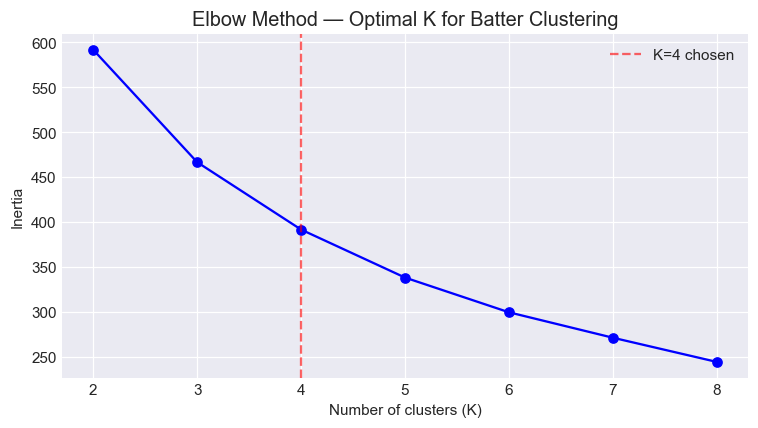

In [26]:
CLUSTER_FEATURES = ['sr', 'dot_pct', 'boundary_pct', 'wkt_rate']
CLUSTER_NAMES    = {
    0: 'Aggressive Attacker',
    1: 'Steady Accumulator',
    2: 'Spin Vulnerable',
    3: 'Balanced Performer',
}

# Only cluster batters with ≥30 balls vs spin
bf_q      = batter_feats[batter_feats['total_balls'] >= 30].copy()
scaler    = StandardScaler()
X_cluster = scaler.fit_transform(bf_q[CLUSTER_FEATURES].fillna(0))

# Elbow method to confirm K=4
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-')
ax.axvline(4, color='red', linestyle='--', alpha=0.6, label='K=4 chosen')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal K for Batter Clustering')
ax.legend()
plt.tight_layout()
plt.show()


Cluster Centroids:
             sr  dot_pct  boundary_pct  wkt_rate
cluster                                         
0         83.87    47.30          6.91      5.42
1        130.19    32.67         14.43      4.03
2        180.85    29.40         25.71      5.99
3        114.07    41.78         12.97      8.45

Batters per cluster: {1: 124, 3: 47, 0: 44, 2: 20}


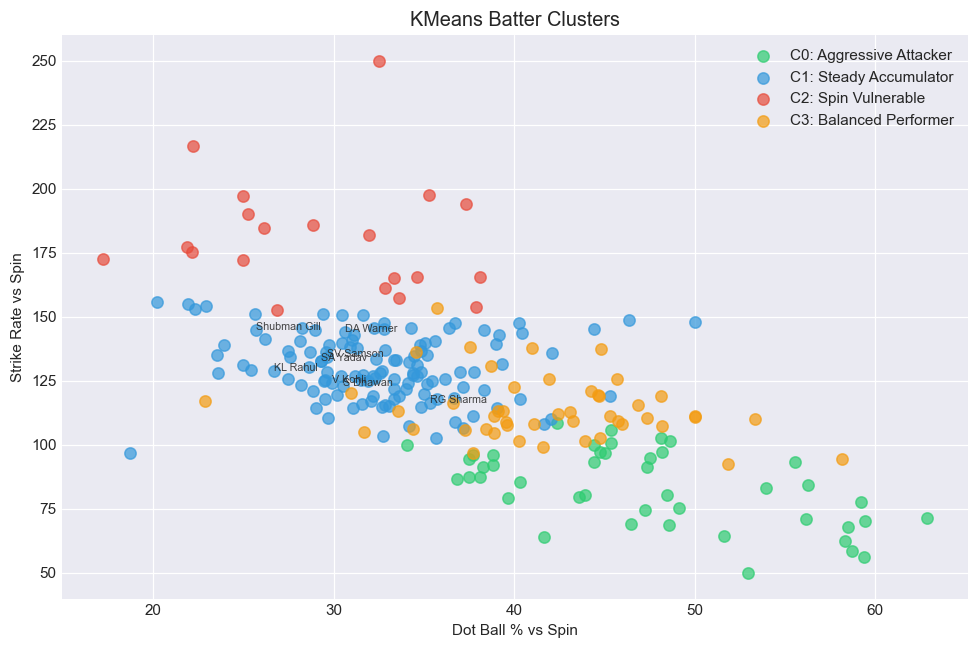


Cluster labels added to batter_feats ✅


In [27]:
# Fit final KMeans with K=4
N_CLUSTERS   = 4
kmeans       = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
bf_q['cluster'] = kmeans.fit_predict(X_cluster)

cluster_summary = bf_q.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
print('Cluster Centroids:')
print(cluster_summary)
print(f'\nBatters per cluster: {bf_q["cluster"].value_counts().to_dict()}')

# Scatter plot
fig, ax = plt.subplots(figsize=(9, 6))
colors   = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for c in range(N_CLUSTERS):
    mask = bf_q['cluster'] == c
    ax.scatter(bf_q[mask]['dot_pct'], bf_q[mask]['sr'],
               s=55, alpha=0.7, color=colors[c],
               label=f'C{c}: {CLUSTER_NAMES[c]}')
ax.set_xlabel('Dot Ball % vs Spin')
ax.set_ylabel('Strike Rate vs Spin')
ax.set_title('KMeans Batter Clusters')
ax.legend()
for _, row in bf_q.nlargest(8, 'total_balls').iterrows():
    ax.annotate(row['Batter'], (row['dot_pct'], row['sr']), fontsize=7, alpha=0.85)
plt.tight_layout()
plt.show()

# Merge cluster labels back into batter_feats
batter_feats = batter_feats.merge(bf_q[['Batter', 'cluster']], on='Batter', how='left')
batter_feats['cluster'] = batter_feats['cluster'].fillna(-1).astype(int)
print('\nCluster labels added to batter_feats ✅')


## 📊 Step 7 — Build Model Dataset

In [28]:
# Encode categorical features
le_spin  = LabelEncoder()
le_phase = LabelEncoder()
spin['spin_type_enc'] = le_spin.fit_transform(spin['spin_type'].astype(str))
spin['phase_enc']     = le_phase.fit_transform(spin['phase'].astype(str))

print('Spin type encoding :')
for i, c in enumerate(le_spin.classes_):  print(f'  {i} → {c}')
print('Phase encoding     :')
for i, c in enumerate(le_phase.classes_): print(f'  {i} → {c}')


Spin type encoding :
  0 → left-arm wrist-spin
  1 → legbreak
  2 → legbreak googly
  3 → right-arm offbreak
  4 → slow left-arm orthodox
Phase encoding     :
  0 → death
  1 → middle
  2 → powerplay


In [29]:
BATTER_COLS = ['Batter', 'sr', 'avg', 'dot_pct', 'boundary_pct',
               'six_pct', 'wkt_rate', 'rotation_pct', 'cluster']

FEATURES = [
    # Delivery context
    'Overs', 'BallNumber', 'Innings',
    'spin_type_enc', 'phase_enc',
    # Ball-level derived
    'ball_in_over_norm', 'is_last_ball', 'over_x_ball', 'is_death_last',
    # Batter career stats
    'sr', 'avg', 'dot_pct', 'boundary_pct',
    'six_pct', 'wkt_rate', 'rotation_pct',
    # Cluster archetype
    'cluster',
    # Venue features
    'venue_spin_wkt_rate', 'venue_spin_economy',
    # Recent form
    'form_sr_last5',
]

model_df = spin.merge(batter_feats[BATTER_COLS].fillna(0), on='Batter', how='left')
model_df = model_df.merge(venue_feats, on='venue', how='left')
model_df = model_df.merge(form_feats,  on='Batter', how='left')

# Fill NaNs from optional features with global means / fallbacks
model_df['venue_spin_wkt_rate'] = model_df['venue_spin_wkt_rate'].fillna(model_df['venue_spin_wkt_rate'].mean())
model_df['venue_spin_economy']  = model_df['venue_spin_economy'].fillna(model_df['venue_spin_economy'].mean())
model_df['form_sr_last5']       = model_df['form_sr_last5'].fillna(model_df['sr'])

model_df = model_df[FEATURES + ['BatsmanRun', 'IsWicketDelivery']].dropna()

print(f'Model dataset : {len(model_df):,} rows × {len(FEATURES)} features')
print(f'Wicket rate   : {model_df["IsWicketDelivery"].mean()*100:.2f}%')

X  = model_df[FEATURES]
yr = model_df['BatsmanRun']
yw = model_df['IsWicketDelivery']

X_tr, X_te, yr_tr, yr_te, yw_tr, yw_te = train_test_split(
    X, yr, yw, test_size=0.2, random_state=42
)
print(f'Train : {len(X_tr):,}  |  Test : {len(X_te):,}')


Model dataset : 60,475 rows × 20 features
Wicket rate   : 4.75%
Train : 48,380  |  Test : 12,095


## 🧠 Step 8 — Train & Compare Models

In [30]:
print('Training all models…\n')

# ── RUNS MODELS ───────────────────────────────────────────────────────────────
runs_models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1),
}

# ── WICKET MODELS ─────────────────────────────────────────────────────────────
wkt_models = {
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, scale_pos_weight=10,
        random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, class_weight='balanced',
        random_state=42, verbose=-1),
}

# ── Train & evaluate runs models ──────────────────────────────────────────────
runs_results = {}
for name, m in runs_models.items():
    m.fit(X_tr, yr_tr)
    preds = m.predict(X_te)
    mae   = mean_absolute_error(yr_te, preds)
    runs_results[name] = {'model': m, 'mae': mae}
    print(f'  Runs  / {name:<20} MAE = {mae:.4f}')

best_runs_name  = min(runs_results, key=lambda n: runs_results[n]['mae'])
best_runs_model = runs_results[best_runs_name]['model']
print(f'\n  Best runs model : {best_runs_name}  (MAE={runs_results[best_runs_name]["mae"]:.4f})')

# ── Train & evaluate wicket models ────────────────────────────────────────────
wkt_results = {}
for name, m in wkt_models.items():
    m.fit(X_tr, yw_tr)
    proba = m.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(yw_te, proba)
    wkt_results[name] = {'model': m, 'auc': auc}
    print(f'  Wicket/ {name:<20} AUC = {auc:.4f}')

best_wkt_name  = max(wkt_results, key=lambda n: wkt_results[n]['auc'])
best_wkt_model = wkt_results[best_wkt_name]['model']
print(f'\n  Best wicket model: {best_wkt_name}  (AUC={wkt_results[best_wkt_name]["auc"]:.4f})')


Training all models…

  Runs  / RandomForest         MAE = 1.1194
  Runs  / XGBoost              MAE = 1.1203
  Runs  / LightGBM             MAE = 1.1194

  Best runs model : RandomForest  (MAE=1.1194)
  Wicket/ GradientBoosting     AUC = 0.6464
  Wicket/ XGBoost              AUC = 0.6419
  Wicket/ LightGBM             AUC = 0.6417

  Best wicket model: GradientBoosting  (AUC=0.6464)


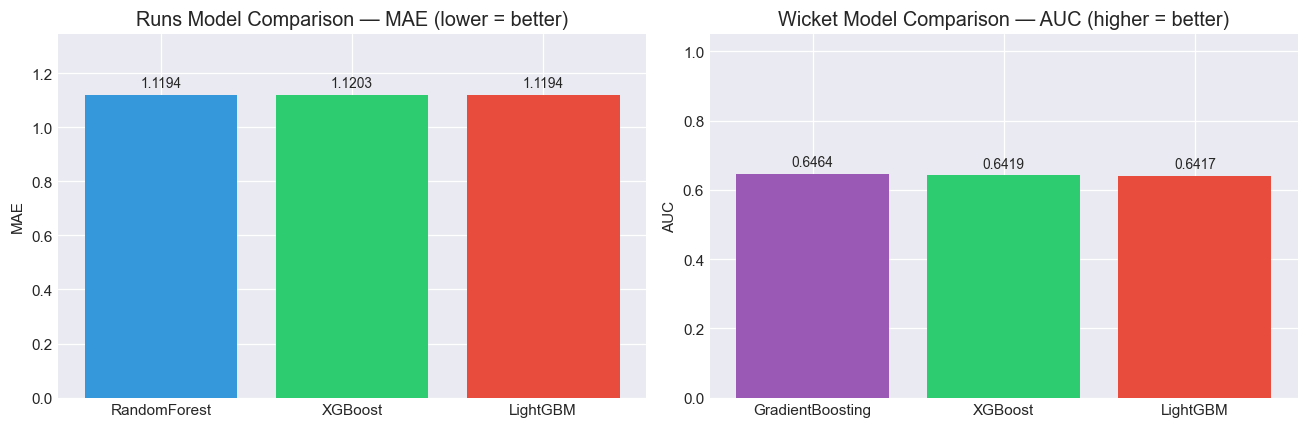

In [31]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

names_r = list(runs_results.keys())
maes    = [runs_results[n]['mae'] for n in names_r]
bars1   = ax1.bar(names_r, maes, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax1.set_title('Runs Model Comparison — MAE (lower = better)')
ax1.set_ylabel('MAE')
ax1.set_ylim(0, max(maes) * 1.2)

names_w = list(wkt_results.keys())
aucs    = [wkt_results[n]['auc'] for n in names_w]
bars2   = ax2.bar(names_w, aucs, color=['#9b59b6', '#2ecc71', '#e74c3c'])
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
ax2.set_title('Wicket Model Comparison — AUC (higher = better)')
ax2.set_ylabel('AUC')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## 🎛️ Step 9 — Hyperparameter Tuning (Best Model)

In [32]:
# Tune the best runs model with RandomizedSearchCV (quick, 20 iterations)
print(f'Tuning {best_runs_name} for runs…')

param_grid_runs = {
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 8, 10, 12],
        'min_samples_leaf': [10, 20, 30],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
    },
}

base_model_r = {
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost'     : xgb.XGBRegressor(random_state=42, verbosity=0),
    'LightGBM'    : lgb.LGBMRegressor(random_state=42, verbose=-1),
}[best_runs_name]

rs_runs = RandomizedSearchCV(
    base_model_r, param_grid_runs[best_runs_name],
    n_iter=20, cv=3, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=0
)
rs_runs.fit(X_tr, yr_tr)
best_runs_model = rs_runs.best_estimator_

tuned_mae = mean_absolute_error(yr_te, best_runs_model.predict(X_te))
print(f'  Tuned {best_runs_name} MAE = {tuned_mae:.4f}  (was {runs_results[best_runs_name]["mae"]:.4f})')
print(f'  Best params: {rs_runs.best_params_}')


Tuning RandomForest for runs…
  Tuned RandomForest MAE = 1.1193  (was 1.1194)
  Best params: {'n_estimators': 300, 'min_samples_leaf': 30, 'max_depth': 6}


In [33]:
# Tune the best wicket model
print(f'\nTuning {best_wkt_name} for wickets…')

param_grid_wkt = {
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
        'scale_pos_weight': [8, 10, 12],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
    },
}

base_model_w = {
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost'         : xgb.XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM'        : lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
}[best_wkt_name]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rs_wkt = RandomizedSearchCV(
    base_model_w, param_grid_wkt[best_wkt_name],
    n_iter=20, cv=skf, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
rs_wkt.fit(X_tr, yw_tr)
best_wkt_model = rs_wkt.best_estimator_

tuned_auc = roc_auc_score(yw_te, best_wkt_model.predict_proba(X_te)[:, 1])
print(f'  Tuned {best_wkt_name} AUC = {tuned_auc:.4f}  (was {wkt_results[best_wkt_name]["auc"]:.4f})')
print(f'  Best params: {rs_wkt.best_params_}')



Tuning GradientBoosting for wickets…
  Tuned GradientBoosting AUC = 0.6566  (was 0.6464)
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


## 🔍 Step 10 — SHAP Explainability

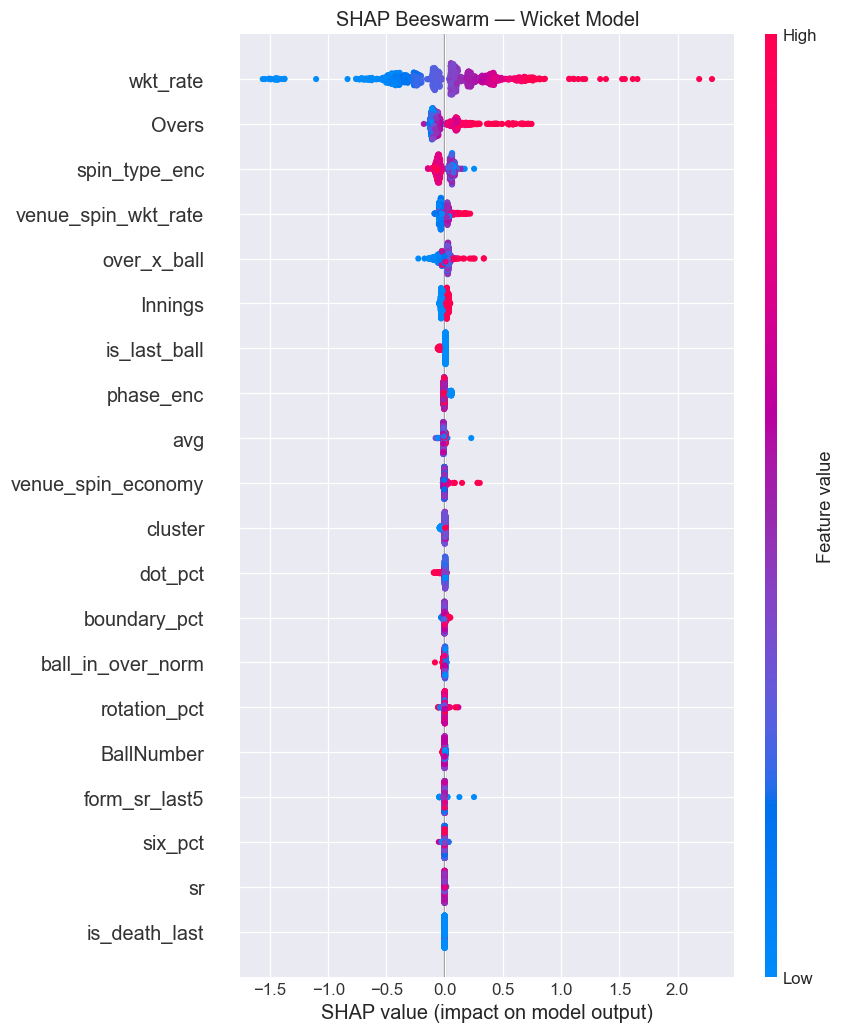

In [34]:
# SHAP explainability for wicket model
explainer_wkt    = shap.TreeExplainer(best_wkt_model)
shap_values_wkt  = explainer_wkt.shap_values(X_te.iloc[:1000])

# Handle binary classifiers that return list of arrays
sv = shap_values_wkt[1] if isinstance(shap_values_wkt, list) else shap_values_wkt

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_te.iloc[:1000], feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Wicket Model')
plt.tight_layout()
plt.show()


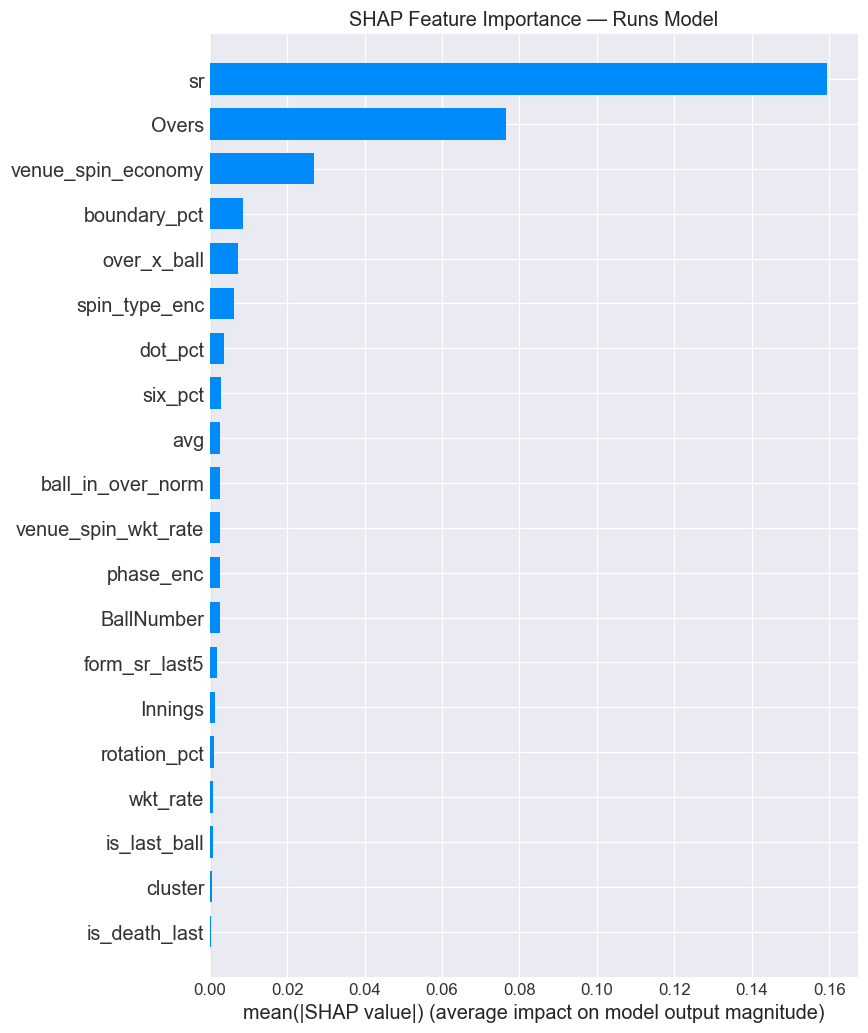

In [35]:
# SHAP for runs model
explainer_runs   = shap.TreeExplainer(best_runs_model)
shap_values_runs = explainer_runs.shap_values(X_te.iloc[:1000])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_runs, X_te.iloc[:1000],
                  feature_names=FEATURES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Runs Model')
plt.tight_layout()
plt.show()


## ✅ Step 11 — Validation

=== Wicket Model ===
              precision    recall  f1-score   support

     Not Out       0.95      1.00      0.98     11515
      Wicket       1.00      0.01      0.01       580

    accuracy                           0.95     12095
   macro avg       0.98      0.50      0.49     12095
weighted avg       0.95      0.95      0.93     12095



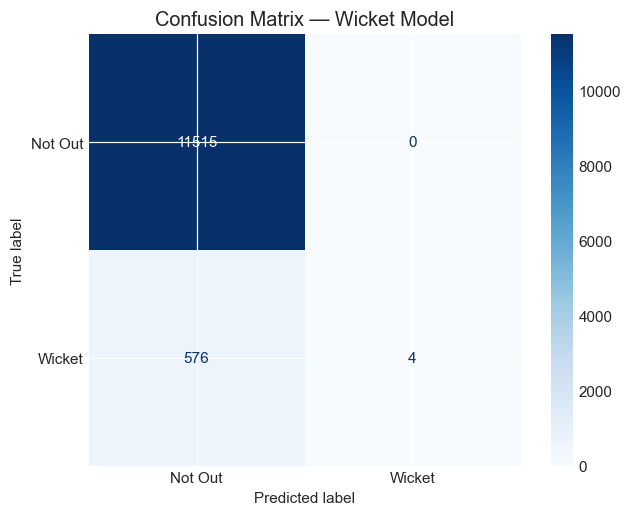

In [36]:
# Wicket model classification report
print('=== Wicket Model ===')
preds_wkt = best_wkt_model.predict(X_te)
print(classification_report(yw_te, preds_wkt, target_names=['Not Out', 'Wicket']))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_wkt_model, X_te, yw_te,
                                       display_labels=['Not Out', 'Wicket'],
                                       cmap='Blues')
plt.title('Confusion Matrix — Wicket Model')
plt.tight_layout()
plt.show()


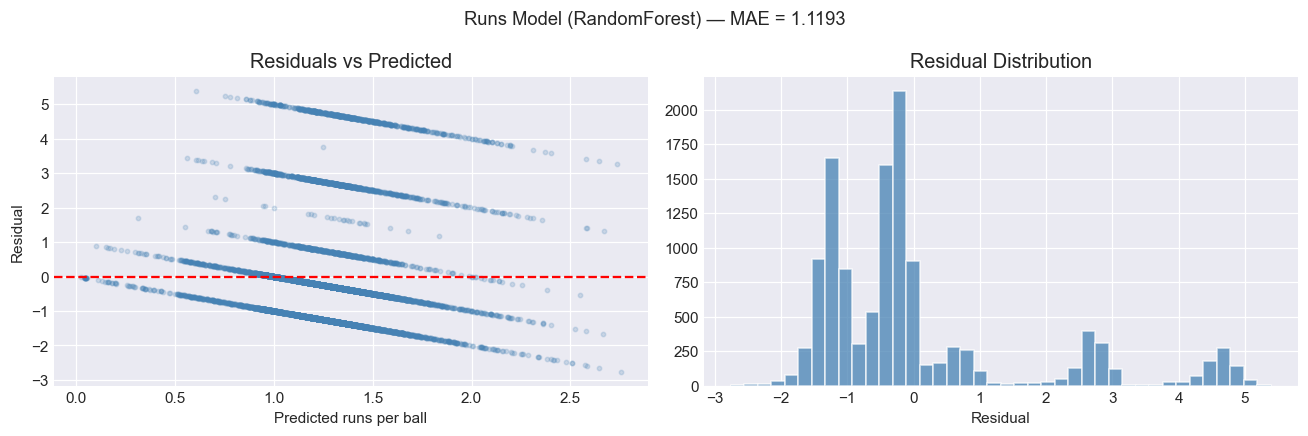

In [37]:
# Runs model residual plot
preds_runs = best_runs_model.predict(X_te)
residuals  = yr_te.values - preds_runs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(preds_runs, residuals, alpha=0.2, s=8, color='steelblue')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted runs per ball')
ax1.set_ylabel('Residual')
ax1.set_title('Residuals vs Predicted')

ax2.hist(residuals, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax2.set_xlabel('Residual')
ax2.set_title('Residual Distribution')

plt.suptitle(f'Runs Model ({best_runs_name}) — MAE = {mean_absolute_error(yr_te, preds_runs):.4f}')
plt.tight_layout()
plt.show()


## 🔮 Step 12 — Prediction Function

In [ ]:
def predict_batter(batter_name, spin_type='right-arm offbreak',
                   phase='middle', innings=1, n_balls=12,
                   venue=None, verbose=True):
    """
    Predict a batter's performance against a spin type.

    Returns a dict with all prediction metrics.
    Returns a dict with Status='NO DATA' / 'INSUFFICIENT DATA' when the batter
    lacks enough recorded balls vs spin — so callers must check before indexing.
    """

    # ── Batter lookup ─────────────────────────────────────────────────────────
    MIN_BALLS = 30

    brow = batter_feats[batter_feats['Batter'] == batter_name]

    # Try last-name match if full name not found
    if brow.empty:
        last = batter_name.split()[-1]
        brow = batter_feats[batter_feats['Batter'].str.contains(last, case=False, na=False)]
        if not brow.empty and verbose:
            print(f"\u26a0 '{batter_name}' matched to '{brow.iloc[0]['Batter']}' by last name")

    # Not in dataset at all
    if brow.empty:
        if verbose:
            print(f"\u26d4 '{batter_name}' has no data against spin bowlers in this dataset.")
        return {
            'batter'               : batter_name,
            'Status'               : 'NO DATA',
            'Message'              : 'Batter has no recorded balls faced against spin bowling.',
            'predicted_sr'         : None,
            'predicted_runs'       : None,
            'expected_runs'        : None,
            'dismissal_prob_pct'   : None,
            'dismiss_in_spell_pct' : None,
            'confidence'           : 'NONE',
        }

    # In dataset but not enough balls
    n_balls_hist = int(brow['total_balls'].values[0])
    if n_balls_hist < MIN_BALLS:
        if verbose:
            print(f"\u26a0 '{batter_name}' has only {n_balls_hist} balls vs spin "
                  f"\u2014 minimum {MIN_BALLS} required.")
        return {
            'batter'               : batter_name,
            'Status'               : 'INSUFFICIENT DATA',
            'Message'              : f'Only {n_balls_hist} balls faced vs spin (minimum {MIN_BALLS} required).',
            'predicted_sr'         : None,
            'predicted_runs'       : None,
            'expected_runs'        : None,
            'dismissal_prob_pct'   : None,
            'dismiss_in_spell_pct' : None,
            'confidence'           : f'TOO LOW ({n_balls_hist} balls)',
        }

    # ── Confidence level ──────────────────────────────────────────────────────
    if n_balls_hist >= 200:
        confidence = 'HIGH'
    elif n_balls_hist >= 100:
        confidence = 'MEDIUM'
    else:
        confidence = 'LOW'

    if verbose:
        print(f"\U0001f4ca '{batter_name}' \u2014 {n_balls_hist} balls vs spin | "
              f"Confidence: {confidence} | Cluster: {int(brow['cluster'].values[0])}")

    # ── Encode spin type and phase ────────────────────────────────────────────
    spin_enc  = int(le_spin.transform([spin_type])[0])  if spin_type in le_spin.classes_  else 0
    phase_enc = int(le_phase.transform([phase])[0])     if phase     in le_phase.classes_ else 1

    # ── Venue lookup ──────────────────────────────────────────────────────────
    vrow  = venue_feats[venue_feats['venue'] == venue] if venue is not None else pd.DataFrame()
    v_wkt = float(vrow['venue_spin_wkt_rate'].values[0]) if not vrow.empty \
            else float(venue_feats['venue_spin_wkt_rate'].mean())
    v_eco = float(vrow['venue_spin_economy'].values[0])  if not vrow.empty \
            else float(venue_feats['venue_spin_economy'].mean())

    # ── Recent form ───────────────────────────────────────────────────────────
    form_row = form_feats[form_feats['Batter'] == batter_name]
    form_sr  = float(form_row['form_sr_last5'].values[0]) if not form_row.empty \
               else float(brow['sr'].values[0])

    # ── Build feature vector (must match FEATURES order exactly) ─────────────
    over_map = {'powerplay': 3, 'middle': 10, 'death': 17}
    over_num = over_map.get(phase.lower(), 10)
    ball_num = 3   # representative mid-over ball

    feat_vals = [
        over_num, ball_num, innings,
        spin_enc, phase_enc,
        ball_num / 6,                           # ball_in_over_norm
        0,                                      # is_last_ball
        over_num * ball_num,                    # over_x_ball
        int(over_num >= 17 and ball_num >= 5),  # is_death_last
        float(brow['sr'].values[0]),
        float(brow['avg'].values[0]),
        float(brow['dot_pct'].values[0]),
        float(brow['boundary_pct'].values[0]),
        float(brow['six_pct'].values[0]),
        float(brow['wkt_rate'].values[0]),
        float(brow['rotation_pct'].values[0]),
        float(brow['cluster'].values[0]),
        v_wkt, v_eco,
        form_sr,
    ]

    X_pred = pd.DataFrame([feat_vals], columns=FEATURES)

    # ── Run models ────────────────────────────────────────────────────────────
    pred_runs_pb   = max(0.0, float(best_runs_model.predict(X_pred)[0]))
    pred_dism_prob = float(best_wkt_model.predict_proba(X_pred)[0][1])

    pred_sr          = round(pred_runs_pb * 100, 1)
    pred_runs_total  = round(pred_runs_pb * n_balls, 1)
    dismissal_pct    = round(pred_dism_prob * 100, 2)
    dismiss_in_spell = round((1 - (1 - pred_dism_prob) ** n_balls) * 100, 1)
    expected_runs    = round(pred_runs_total * (1 - pred_dism_prob), 1)

    if verbose:
        print()
        print('\u2550' * 58)
        print(f'  \U0001f3cf {batter_name}')
        print(f'  vs {spin_type}  |  {phase}  |  inn {innings}  |  venue: {venue or "unknown"}')
        print('\u2550' * 58)
        print(f'  Predicted Strike Rate       : {pred_sr}')
        print(f'  Predicted Runs ({n_balls} balls)    : {pred_runs_total}')
        print(f'  Dismissal prob / ball       : {dismissal_pct}%')
        print(f'  Dismissal prob in spell     : {dismiss_in_spell}%')
        print(f'  \u2605 Expected Runs (adj. risk) : {expected_runs}')
        print(f'  Confidence                  : {confidence}')
        print(f'  Historical SR vs spin       : {round(float(brow["sr"].values[0]), 1)}')
        print('\u2550' * 58)

    return {
        'batter'               : batter_name,
        'spin_type'            : spin_type,
        'phase'                : phase,
        'predicted_sr'         : pred_sr,
        'predicted_runs'       : pred_runs_total,
        'expected_runs'        : expected_runs,
        'dismissal_prob_pct'   : dismissal_pct,
        'dismiss_in_spell_pct' : dismiss_in_spell,
        'confidence'           : confidence,
        'Status'               : 'OK',
    }


print('\u2705 predict_batter() ready')


## 🎲 Step 13 — Monte Carlo Simulation

In [39]:
def monte_carlo_simulate(batter_name, spin_type, phase, innings=1,
                          n_balls=12, n_simulations=1000, venue=None):
    """
    Simulate n_simulations possible innings for a batter against spin.
    On each ball: dismissed with probability pred_dism_prob, else scores
    runs sampled from their historical ball-level distribution.
    Returns array of total runs simulated.
    """
    pred = predict_batter(batter_name, spin_type, phase, innings,
                          n_balls, venue, verbose=False)

    # ── Guard: bail out cleanly if batter has no/insufficient data ────────────
    if pred.get('Status') in ('NO DATA', 'INSUFFICIENT DATA'):
        print(f"\u26a0  Cannot simulate '{batter_name}': {pred.get('Message', pred.get('Status'))}")
        return np.array([])

    dism_prob = pred['dismissal_prob_pct'] / 100

    # Use batter-specific ball distribution; fall back to full spin dataset
    batter_balls = spin[spin['Batter'] == batter_name]['BatsmanRun'].values
    if len(batter_balls) < 20:
        batter_balls = spin['BatsmanRun'].values

    np.random.seed(42)
    totals = []
    for _ in range(n_simulations):
        total = 0
        for _ in range(n_balls):
            if np.random.random() < dism_prob:
                break
            total += int(np.random.choice(batter_balls))
        totals.append(total)
    totals = np.array(totals)

    print(f'\n\U0001f3b2 Monte Carlo \u2014 {batter_name} vs {spin_type} ({phase}, {n_simulations:,} simulations)')
    print(f'   Mean                : {totals.mean():.1f}')
    print(f'   Median              : {np.median(totals):.1f}')
    print(f'   P10 (worst 10%)     : {np.percentile(totals,10):.1f}')
    print(f'   P90 (best  10%)     : {np.percentile(totals,90):.1f}')
    print(f'   P(\u226515 runs)         : {(totals>=15).mean()*100:.1f}%')
    print(f'   P(dismissed duck)   : {(totals==0).mean()*100:.1f}%')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(totals, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(totals.mean(),            color='red',    linestyle='--', label=f'Mean={totals.mean():.1f}')
    ax.axvline(np.percentile(totals,10), color='orange', linestyle=':',  label=f'P10={np.percentile(totals,10):.1f}')
    ax.axvline(np.percentile(totals,90), color='green',  linestyle=':',  label=f'P90={np.percentile(totals,90):.1f}')
    ax.set_xlabel(f'Total Runs in {n_balls} Balls')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Monte Carlo: {batter_name} vs {spin_type} ({phase})')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return totals


# ── Example ────────────────────────────────────────────────────────────────────
_ = monte_carlo_simulate('RG Sharma', 'legbreak', phase='middle', n_balls=12)


TypeError: 'NoneType' object is not subscriptable

## 🏟️ Step 14 — Full Match Prediction

In [ ]:
# ── Check 1: Which XI batters are missing from batter_features ──
xi = ['DP Conway', 'M Theekshana', 'DS Kulkarni', 'MJ Santner', 
      'SB Dube', 'RA Jadeja']  # your full XI here

missing_bf = [b for b in xi if batter_feats[batter_feats['Batter'] == b].empty]
print("❌ Missing from batter_features.csv:", missing_bf)

# ── Check 2: Venue name exact match ──
venue = 'Wankhede Stadium'
match = venue_feats[venue_feats['venue'].str.lower() == venue.lower()]
print("❌ Venue match:" if match.empty else "✅ Venue found:", venue)
print("Available venues:", venue_feats['venue'].tolist())

# ── Check 3: Which batters missing from form_features ──
missing_ff = [b for b in xi if form_feats[form_feats['Batter'] == b].empty]
print("❌ Missing from form_features.csv:", missing_ff)

In [ ]:
def predict_match_vs_spin(batting_xi, bowling_team_xi, venue, phase, n_balls=12):
    """
    Predict all batters in batting_xi against the spin bowlers in bowling_team_xi.
    Skips batters with no / insufficient spin data and reports them separately.
    Returns a DataFrame sorted by expected_runs descending.
    """
    # Identify spin bowlers in bowling team
    spin_bowlers_in_team = [
        (b, spin_map[b]) for b in bowling_team_xi if b in spin_map
    ]

    if not spin_bowlers_in_team:
        print('\u26a0 No spin bowlers found in bowling XI')
        return pd.DataFrame()

    print('Spin bowlers identified in bowling team:')
    for b, t in spin_bowlers_in_team:
        print(f'  {b} \u2014 {t}')
    print()

    # Use primary spin type (most common in the XI)
    from collections import Counter
    primary_spin = Counter(t for _, t in spin_bowlers_in_team).most_common(1)[0][0]

    results = []
    skipped = []

    for batter in batting_xi:
        r = predict_batter(batter, spin_type=primary_spin,
                           phase=phase, n_balls=n_balls,
                           venue=venue, verbose=False)

        if r.get('Status') in ('NO DATA', 'INSUFFICIENT DATA'):
            skipped.append(r)
            print(f"\u23ed  Skipped: {batter} \u2014 {r.get('Message', r.get('Status'))}")
            continue

        results.append(r)

    if skipped:
        print(f"\n\u26a0  {len(skipped)} batter(s) skipped due to insufficient spin data:")
        for s in skipped:
            print(f"   \u2022 {s['batter']}: {s.get('Message', '')}")

    if not results:
        print('\u274c No batters had enough spin data to predict.')
        return pd.DataFrame()

    df = pd.DataFrame(results)[[
        'batter', 'predicted_sr', 'predicted_runs', 'expected_runs',
        'dismissal_prob_pct', 'dismiss_in_spell_pct', 'confidence'
    ]].rename(columns={
        'batter'               : 'Batter',
        'predicted_sr'         : 'Pred SR',
        'predicted_runs'       : 'Pred Runs',
        'expected_runs'        : 'Expected Runs',
        'dismissal_prob_pct'   : 'Dismissal %',
        'dismiss_in_spell_pct' : 'Dismiss in Spell %',
        'confidence'           : 'Confidence',
    }).sort_values('Expected Runs', ascending=False).reset_index(drop=True)

    return df


In [ ]:
# ── Define your match and run the prediction ─────────────────────────────────
# Edit these two XIs and the venue/phase to match the fixture you want to predict

match = {
    'team1' : 'Mumbai Indians',        # batting team
    'team2' : 'Chennai Super Kings',   # bowling team
    'venue' : 'Wankhede Stadium',
    'phase' : 'middle',                # 'powerplay' | 'middle' | 'death'
}

# Replace with the actual playing XI names (must match names in batter_features.csv)
batting_xi = [
    'RG Sharma', 'IR Pandya', 'SA Yadav', 'TM Head',
    'N Tilak Varma', 'AT Rayudu', 'KA Pollard',
    'KH Pandya', 'JJ Bumrah', 'B Kumar', 'TG Southee',
]

bowling_xi = [
    'RA Jadeja', 'AS Rajpoot', 'MS Pathirana',
    'Imran Tahir', 'DL Chahar', 'SN Thakur',
]

# ── Run the full match prediction ─────────────────────────────────────────────
result_df = predict_match_vs_spin(
    batting_xi      = batting_xi,
    bowling_team_xi = bowling_xi,
    venue           = match['venue'],
    phase           = match['phase'],
    n_balls         = 12,
)

if not result_df.empty:
    print()
    print(result_df.to_string(index=False))


In [ ]:
# Visualise match prediction results
if not result_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    colors_r = ['#2ecc71' if x > 120 else '#f39c12' if x > 90 else '#e74c3c'
                for x in result_df['Pred SR']]
    ax1.barh(result_df['Batter'], result_df['Expected Runs'], color=colors_r)
    ax1.set_title('Expected Runs vs Spin (dismissal-adjusted)')
    ax1.set_xlabel('Expected Runs')
    ax1.invert_yaxis()

    # Column is 'Dismissal %' (probability per ball × 100)
    colors_d = ['#2ecc71' if x < 6 else '#f39c12' if x < 10 else '#e74c3c'
                for x in result_df['Dismissal %']]
    ax2.barh(result_df['Batter'], result_df['Dismissal %'], color=colors_d)
    ax2.set_title('Dismissal Probability per Ball (%)')
    ax2.set_xlabel('Probability (%)')
    ax2.invert_yaxis()

    plt.suptitle(
        f"{match.get('team1','Batting XI')} vs Spin — {match.get('venue','')}",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
else:
    print('⚠  No results to visualise — check that batter names match batter_features.csv')


## 💾 Step 15 — Save All Artefacts

In [ ]:
# ── Models & encoders ────────────────────────────────────────────────────────
joblib.dump(best_runs_model, 'model_runs.pkl')
joblib.dump(best_wkt_model,  'model_wicket.pkl')
joblib.dump(le_spin,         'encoder_spin.pkl')
joblib.dump(le_phase,        'encoder_phase.pkl')
joblib.dump(scaler,          'scaler_cluster.pkl')
joblib.dump(kmeans,          'model_kmeans.pkl')

# ── CSVs (used by app.py at runtime) ─────────────────────────────────────────
batter_feats.to_csv('batter_features.csv', index=False)
venue_feats.to_csv('venue_features.csv',   index=False)
form_feats.to_csv('form_features.csv',     index=False)

# ── Batter vs spin breakdown (used by /player-stats endpoint) ─────────────────
bvs = spin.groupby(['Batter', 'spin_type']).agg(
    balls      = ('BatsmanRun', 'count'),
    runs       = ('BatsmanRun', 'sum'),
    dismissals = ('IsWicketDelivery', 'sum'),
).reset_index()
bvs['sr']  = (bvs['runs'] / bvs['balls'] * 100).round(1)
bvs['avg'] = (bvs['runs'] / bvs['dismissals'].replace(0, np.nan)).fillna(bvs['runs']).round(1)
bvs.rename(columns={'spin_type': 'bowler_spin_type'}, inplace=True)
bvs.to_csv('batter_vs_spin_stats.csv', index=False)

print('✅ All artefacts saved:')
for f in ['model_runs.pkl', 'model_wicket.pkl', 'encoder_spin.pkl',
          'encoder_phase.pkl', 'model_kmeans.pkl', 'scaler_cluster.pkl',
          'batter_features.csv', 'venue_features.csv', 'form_features.csv',
          'batter_vs_spin_stats.csv']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f'  {f:<35} {size/1024:>7.1f} KB')
